In [ ]:
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE 
from data_processing import load_data,split_data,compute_step,get_slope
import math
import os
from scipy.stats import zscore
from scipy.stats import norm
def loaddata1(dirs):
    data_dir = dirs
    df20 = load_data(data_dir)
    grouped20 = split_data(df20)
    bias20 = df20['Bias (V)'].values.round(1)
    return df20,grouped20,bias20
T = -4.5  # 阈值

# -----------------------
# 特征提取函数
# -----------------------
def extract_features(seq):
    x = np.asarray(seq, dtype=np.float32)
    N = len(x)
    mu = x.mean()
    dmu = mu - T
    sigma = (np.sum(np.abs(x-mu)>0.1))/len(x)
    p_above = (x > T).mean()
    if p_above<=0.001 or p_above>=0.999:
         cross1 = 0
         cross2 = 1
    else:
        cross1 =  (x[0:(int(N*p_above))]>T).mean()# 穿越率
        cross2 = (x[0:(int(N*(1-p_above)))]<T).mean()
    

    return np.array([dmu, sigma, cross1 ,cross2, p_above], dtype=np.float32)

def weak_label_from_series(feat):
    dmu = feat[0]
    sigma = feat[1]
    cross1 = feat[2]
    cross2 = feat[3]
    p_above = feat[4]
    if p_above>=0.1 and p_above<=0.9:  # 有高有低
        if cross1>0.85:
            label = 4 # high-low
            conf = min(0.9,cross1)
        elif cross2>0.85:
            label = 5 #low-high
            conf = min(0.9,cross2)
        elif abs(dmu) <= 0.1  :
            if dmu<0.1 and dmu>=0:
                label = 6  # high-Fuzzy
                conf = min(0.9,0.6 + (p_above - 0.3))  # 可变置信
            else:
                label = 7  # low-Fuzzy
                conf = min(0.9,0.6 + 4*(p_above - 0.3))  # 可变置信
        else:
             label = 8
             conf = min(0.9,1-0.2*cross1)
    elif dmu > 0.05 and p_above>0.9:
        if sigma>=0.2:
            label = 0 # 高导但是很抖
            conf = min(0.9,0.8+0.2*sigma)
        else:
            label = 1 #高导且很平稳
            conf = min(0.9, 1-0.5*sigma)
    elif dmu<-0.05 and p_above<0.1:
        if sigma>=0.2:
            label = 2 # 低导但是很抖
            conf = min(0.9,0.8+0.2*sigma)
        else:
            label = 3 #低导且很平稳
            conf = min(0.9, 1-0.5*sigma)
    else:
        label = 8
        conf = min(0.9,1-0.2*cross1)
    return label, conf
def compute_global_eps(all_series):
    vals = np.concatenate([np.abs(s - T) for s in all_series])
    return np.quantile(vals, 0.25)  # 25% 分位数作为邻域宽度


def conputerconf(data,labels):
    confidence = []
    for i in np.arange(0,len(labels)):
        feat = data[i]
        label = labels[i]
        dmu = feat[0]
        sigma = feat[1]
        cross = feat[2]
        p_band = feat[3]
        p_above = feat[4]
        if label == 4:
            conf = min(0.9,cross)  # 可变置信
        elif label == 5: # high-low
                conf = min(0.9,1-cross)
        elif label == 6: #low-high
                conf = min(0.9,1-0.2*cross)
        elif label == 7 or label==8:#纯抖动:
                conf = min(0.9,0.6 + 4*(p_band - 0.3)) 
             
        elif label == 0: # 高导但是很抖
                conf = min(0.9,0.2+0.8*sigma)
        elif label == 1 :#高导且很平稳
                conf = min(0.9, 1-0.3*sigma)
        elif label == 2: # 高导但是很抖
                conf = min(0.9,0.2+0.8*sigma)
        elif label == 3: #高导且很平稳
                conf = min(0.9, 1-0.3*sigma)
        confidence.append(conf)
    return np.array(confidence)


In [ ]:
validdata20 = pd.read_csv('./validdata20.csv')
validdata30 = pd.read_csv('./validdata30.csv')
validdataread = pd.read_csv('./validdataread.csv')
minbias = -1.5
maxbias = 1.5


X_train = []
y_train = []
confidence = []
raw_groups = []
for group_num,group_data in validdata20.groupby('Number'):
    # if group_num <10:
    # if  group_num in num or group_num in s_num or group_num in hhh_num or group_num in lll_num:
    # if  group_num <100:
    # if group_num in[566]:
    # if group_num==2220 or group_num==2265 or group_num==2421:
        bias = group_data['Bias (V)'].values.round(1)
        conduct = group_data['Log(G/G0)'].values
        prev_bias = bias[:-1]
        next_bias = bias[1:]
        # R1的起始索引
        idx_1_01 = np.where((prev_bias == 1.5) & (next_bias == 0.1))[0] + 1
        idx_01_n1 = np.where((prev_bias == 0.1) & (next_bias == -1.5))[0] + 1
        # R2的开始索引
        idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1

        # 计算电导长度
        idx_01_10 = np.where((prev_bias == 0.1) & (next_bias == maxbias))[0]
        # 截取忆阻判断的两段   
        # print(idx_1_01,idx_01_n1)  
        if len(idx_1_01)>0 and len(idx_01_n1)>0 and len(idx_n1_01)>0: 
            R0 = group_data[2200:idx_01_10[0]-50]
            Rmax = group_data[idx_01_10[0]+200:idx_1_01[0]-50]                                                                                                                      
            R1 = group_data[idx_1_01[0]+200:idx_01_n1[0]-50]
            Rmin = group_data[idx_01_n1[0]+200:idx_n1_01[0]-50]
            R2 = group_data[idx_n1_01[0]+200:-50]   
                
            feat = extract_features(R0['Log(G/G0)'].values)
                        # print(feat)
            labelcur,conf = weak_label_from_series(feat)
            X_train.append(feat)
            y_train.append(labelcur)    
            confidence.append(conf)                   
            raw_groups.append(R0['Log(G/G0)'].values)
            # print(class_names[labelcur],conf)
            feat = extract_features(R1['Log(G/G0)'].values)
            # print(feat)
            labelcur,conf = weak_label_from_series(feat)
            X_train.append(feat)
            y_train.append(labelcur)    
            confidence.append(conf)                   
            raw_groups.append(R1['Log(G/G0)'].values)
            # print(class_names[labelcur],conf)
            feat = extract_features(R2['Log(G/G0)'].values)
            # print(feat)
            labelcur,conf = weak_label_from_series(feat)
            X_train.append(feat)
            y_train.append(labelcur)    
            confidence.append(conf)                   
            raw_groups.append(R2['Log(G/G0)'].values)
                # print(seq)
                # plt.plot(group_data['Log(G/G0)'].values)
                # plt.ylim(-5.8,-3)
                # plt.hlines(y=-4.5,xmin=0,xmax=12000)
                # plt.show()
len(X_train),len(y_train),len(confidence)

(4161, 4161, 4161)

In [ ]:
X_test = []
y_test = []
confidence_test = []
raw_groups_test = []
for group_num,group_data in validdata30.groupby('Number'):
    # if group_num <10:
    # if  group_num in num or group_num in s_num or group_num in hhh_num or group_num in lll_num:
    # if  group_num <100:
    # if group_num in[566]:
    # if group_num==2220 or group_num==2265 or group_num==2421:
        bias = group_data['Bias (V)'].values.round(1)
        conduct = group_data['Log(G/G0)'].values
        prev_bias = bias[:-1]
        next_bias = bias[1:]
        # R1的起始索引
        idx_1_01 = np.where((prev_bias == 1.5) & (next_bias == 0.1))[0] + 1
        idx_01_n1 = np.where((prev_bias == 0.1) & (next_bias == -1.5))[0] + 1
        # R2的开始索引
        idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1

        # 计算电导长度
        idx_01_10 = np.where((prev_bias == 0.1) & (next_bias == maxbias))[0]
        # 截取忆阻判断的两段   
        # print(idx_1_01,idx_01_n1)  
        if len(idx_1_01)>0 and len(idx_01_n1)>0 and len(idx_n1_01)>0: 
            R0 = group_data[2200:idx_01_10[0]-50]
            Rmax = group_data[idx_01_10[0]+200:idx_1_01[0]-50]                                                                                                                      
            R1 = group_data[idx_1_01[0]+200:idx_01_n1[0]-50]
            Rmin = group_data[idx_01_n1[0]+200:idx_n1_01[0]-50]
            R2 = group_data[idx_n1_01[0]+200:-50]   
                
            feat = extract_features(R0['Log(G/G0)'].values)
            # print(feat)
            labelcur,conf = weak_label_from_series(feat)
            X_test.append(feat)
            y_test.append(labelcur)    
            confidence_test.append(conf)                   
            raw_groups_test.append(R0['Log(G/G0)'].values)
            # print(class_names[labelcur],conf)
            feat = extract_features(R1['Log(G/G0)'].values)
            # print(feat)
            labelcur,conf = weak_label_from_series(feat)
            X_test.append(feat)
            y_test.append(labelcur)    
            confidence_test.append(conf)                   
            raw_groups_test.append(R1['Log(G/G0)'].values)
            # print(class_names[labelcur],conf)
            feat = extract_features(R2['Log(G/G0)'].values)
            # print(feat)
            labelcur,conf = weak_label_from_series(feat)
            X_test.append(feat)
            y_test.append(labelcur)    
            confidence_test.append(conf)                   
            raw_groups_test.append(R2['Log(G/G0)'].values)
            # print(class_names[labelcur],conf)
            # plt.plot(group_data['Log(G/G0)'].values)
            # plt.ylim(-5.8,-3)
            # plt.hlines(y=-4.5,xmin=0,xmax=12000)
            # plt.show()
# df20 = validdata20
len(X_test),len(y_test),len(confidence_test)

(1974, 1974, 1974)

In [ ]:
def train_clf(X_train, y_train,conf_train,X_test,y_test,conf_test,n_estimators=200, max_depth=None):

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train, y_train, sample_weight=conf_train)

    # 在测试集上预测
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred, sample_weight=conf_test)
    print("测试集加权准确率:", acc)
    print(classification_report(y_test, y_pred))

    return clf


def tune_hyperparams_with_plot(X, y, conf,n_es,max_de):
    param_grid = {
        "n_estimators": n_es,
        "max_depth": max_de
    }
    clf = RandomForestClassifier(random_state=42)

    # 不使用多进程，避免 BrokenProcessPool
    grid = GridSearchCV(clf, param_grid, cv=3, scoring="accuracy", n_jobs=1, return_train_score=True)
    grid.fit(X, y, sample_weight=conf)

    print("最佳参数:", grid.best_params_)
    print("最佳交叉验证得分:", grid.best_score_)

    results = pd.DataFrame(grid.cv_results_)


    return grid.best_params_, results



def predict_one_rf(clf, seq):
    feat= extract_features(seq).reshape(1, -1)
    pred = clf.predict(feat)[0]
    prob = clf.predict_proba(feat)[0]
    # class_names = ["High-spark", "High-stable", "Low-spark", "Low-stable","high-low","low-high","high-Fuzzy","low-Fuzzy","sparkspark"]
    return pred, max(prob)
# -----------------------
# 绘制测试集预测结果
# -----------------------
def plot_test_predictions(y_true, y_pred, groups, n=5):
    class_names = ["High-spark", "High-stable", "Low-spark", "Low-stable","high-low","low-high","high-Fuzzy","low-Fuzzy","sparkspark"]
    for i in range(min(n, len(groups))):
        seq = groups[i]
        plt.figure(figsize=(8,3))
        plt.plot(seq, label="Log(G/G0)")
        plt.title(f"Test Group {i} - True: {class_names[y_true[i]]}, Pred: {class_names[y_pred[i]]}")
        plt.xlabel("Index")
        plt.ylabel("Log(G/G0)")
        plt.legend()
        plt.show()

In [ ]:
n_esti = np.arange(50,150,20)
max_de = [8,9,10,11,12]
best_params1, results1 = tune_hyperparams_with_plot(X_train, y_train, confidence,n_esti,max_de) 

最佳参数: {'max_depth': 9, 'n_estimators': np.int64(110)}
最佳交叉验证得分: 0.9966354241768806


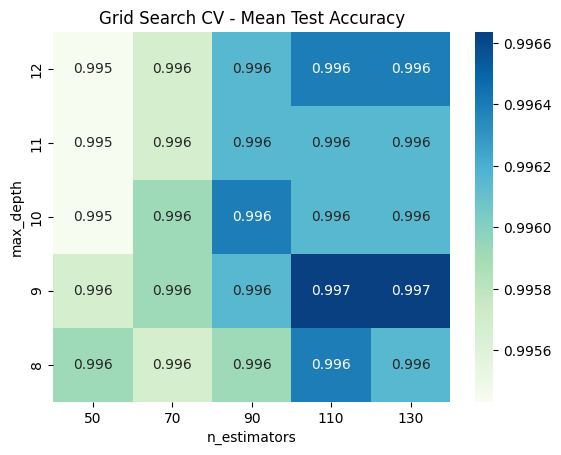

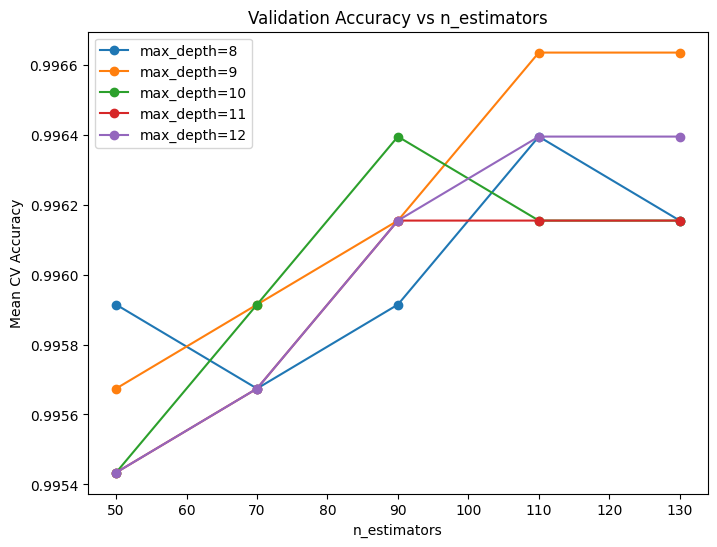

In [ ]:
# results1 = pd.read_csv('./GridSearch1.csv')
results1["param_max_depth"] = results1["param_max_depth"].astype(int)
results1["param_n_estimators"] = results1["param_n_estimators"].astype(int)

# 热力图

pivot = results1.pivot(index="param_max_depth", columns="param_n_estimators", values="mean_test_score")
# plt.figure(figsize=(8, 6))
fig,ax = plt.subplots()
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="GnBu")
ax.invert_yaxis()
plt.title("Grid Search CV - Mean Test Accuracy")
plt.ylabel("max_depth")
plt.xlabel("n_estimators")
plt.show()

# 曲线图
plt.figure(figsize=(8, 6))
for depth in sorted(set(results1["param_max_depth"])):
    subset = results1[results1["param_max_depth"] == depth]
    plt.plot(subset["param_n_estimators"], subset["mean_test_score"], marker="o", label=f"max_depth={depth}")
plt.title("Validation Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Mean CV Accuracy")
plt.legend()
# plt.grid(True)
plt.show()

In [ ]:
clf = train_clf(X_train, y_train,confidence,X_test,y_test,confidence_test,n_estimators=110, max_depth=9)

测试集加权准确率: 0.9980302429039217
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       282
           1       1.00      1.00      1.00       756
           2       1.00      1.00      1.00       278
           3       1.00      1.00      1.00       280
           4       1.00      1.00      1.00        78
           5       1.00      0.99      0.99        70
           6       1.00      1.00      1.00        80
           7       1.00      1.00      1.00        92
           8       0.98      0.97      0.97        58

    accuracy                           1.00      1974
   macro avg       1.00      0.99      1.00      1974
weighted avg       1.00      1.00      1.00      1974



In [ ]:
import pickle
with open('clf.pkl', 'wb') as f:
    pickle.dump(clf, f)

In [ ]:
# cluster
def modify_value(x):
    #高导
    if x==0 :
        return 10
    elif x==1:
        return 15
    elif x==6 :
        return 20
    elif x==2 :
        return 40
    elif x==3 :
        return 45
    elif x==7 :
        return 50
    elif x==4 :
        return 70
    elif x==5:
        return 90
    elif x==8:
        return -1

def getdata(validdata20,num):
    data20 = []
    for group_num,group_data in validdata20.groupby('Number'):
        # if group_num <10:
        # if  group_num in num or group_num in s_num or group_num in hhh_num or group_num in lll_num:
        # if  group_num <100:
        # if group_num in[566]:
        # if group_num==2220 or group_num==2265 or group_num==2421:
            bias = group_data['Bias (V)'].values.round(1)
            conduct = group_data['Log(G/G0)'].values
            prev_bias = bias[:-1]
            next_bias = bias[1:]
            # R1的起始索引
            idx_1_01 = np.where((prev_bias == 1.5) & (next_bias == 0.1))[0] + 1
            idx_01_n1 = np.where((prev_bias == 0.1) & (next_bias == -1.5))[0] + 1
            # R2的开始索引
            idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1

            # 计算电导长度
            idx_01_10 = np.where((prev_bias == 0.1) & (next_bias == maxbias))[0]
            # 截取忆阻判断的两段   
            # print(idx_1_01,idx_01_n1)  
            if len(idx_1_01)>0 and len(idx_01_n1)>0 and len(idx_n1_01)>0: 
                R0 = group_data[2200:idx_01_10[0]-50]                                                                                                                     
                R1 = group_data[idx_1_01[0]+200:idx_01_n1[0]-50]
                R2 = group_data[idx_n1_01[0]+200:-50]   
                    
                f0,prob0 = predict_one_rf(clf,R0['Log(G/G0)'].values) 
                f1,prob1 = predict_one_rf(clf,R1['Log(G/G0)'].values) 
                f2,prob2 = predict_one_rf(clf,R2['Log(G/G0)'].values) 
                seq = {
                        'R0':f0,
                        'R1':f1,
                        'R2':f2,
                        'f0':modify_value(f0)*prob0,
                        'f1':modify_value(f1)*prob1,
                        'f2':modify_value(f2)*prob2,
                        'prob0':prob0,
                        'prob1':prob1,
                        'prob2':prob2,
                        'num':group_num + num
                }
                data20.append(seq)
                    # print(seq)
                    # plt.plot(group_data['Log(G/G0)'].values)
                    # plt.ylim(-5.8,-3)
                    # plt.hlines(y=-4.5,xmin=0,xmax=12000)
                    # plt.show()
    data20 = pd.DataFrame(data20)
    return data20

In [ ]:
data20 = getdata(validdata20,0)
data30 = getdata(validdata30,2500)
dataread = getdata(validdataread,4000)
data20,data30,dataread

(      R0  R1  R2         f0         f1         f2     prob0     prob1  \
 0      0   0   0  10.000000  10.000000   9.911936  1.000000  1.000000   
 1      0   5   7  10.000000  83.631585  48.760146  1.000000  0.929240   
 2      0   5   4   9.984974  85.059715  67.027595  0.998497  0.945108   
 3      1   0   6  13.772727  10.000000  18.812714  0.918182  1.000000   
 4      1   2   1  15.000000  39.830297  15.000000  1.000000  0.995757   
 ...   ..  ..  ..        ...        ...        ...       ...       ...   
 1382   0   1   1  10.000000  15.000000  15.000000  1.000000  1.000000   
 1383   1   1   1  15.000000  15.000000  15.000000  1.000000  1.000000   
 1384   1   2   3  14.995733  39.764173  44.856215  0.999716  0.994104   
 1385   7   4   7  44.961567  64.725712  29.795470  0.899231  0.924653   
 1386   0   3   3   9.911936  45.000000  45.000000  0.991194  1.000000   
 
          prob2   num  
 0     0.991194     2  
 1     0.975203     3  
 2     0.957537     9  
 3     0.94063

In [ ]:
df613,grouped613,bias613 = loaddata1('../data411/20250613')
maxbias613= max(bias613)
minbias613 = min(bias613)
data613 = []
validdata613 = pd.DataFrame()
for group_num,group_data in grouped613:
        # if group_num <10:
        # if  group_num in num or group_num in s_num or group_num in hhh_num or group_num in lll_num:
        # if  group_num <100:
        # if group_num in[566]:
        # if group_num==2220 or group_num==2265 or group_num==2421:
            bias = group_data['Bias (V)'].values.round(1)
            conduct = group_data['Log(G/G0)'].values
            prev_bias = bias[:-1]
            next_bias = bias[1:]
            # R1的起始索引
            idx_1_01 = np.where((prev_bias == 1.5) & (next_bias == 0.1))[0] + 1
            idx_01_n1 = np.where((prev_bias == 0.1) & (next_bias == -1.5))[0] + 1
            # R2的开始索引
            idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1

            # 计算电导长度
            idx_01_10 = np.where((prev_bias == 0.1) & (next_bias == maxbias))[0]
            # 截取忆阻判断的两段   
            # print(idx_1_01,idx_01_n1)  
            if len(idx_1_01)>0 and len(idx_01_n1)>0 and len(idx_n1_01)>0: 
                R0 = group_data[2200:idx_01_10[0]-50]
                Rmax = group_data[idx_01_10[0]+200:idx_1_01[0]-50]                                                                                                                      
                R1 = group_data[idx_1_01[0]+200:idx_01_n1[0]-50]
                Rmin = group_data[idx_01_n1[0]+200:idx_n1_01[0]-50]
                R2 = group_data[idx_n1_01[0]+200:-50]   
                data_len = min(len(R0), len(Rmax), len(R1), len(Rmin), len(R2))
                # print(data_len)
                if(data_len>1500):
                    Cr0 = R0['Log(G/G0)'].values[:data_len].round(1)
                    Cr1 = R1['Log(G/G0)'].values[:data_len].round(1)
                    Cr2 = R2['Log(G/G0)'].values[:data_len].round(1)
                    # print(len(Cr0),len(Cr1),len(Cr2))
                    crmax = Rmax['Log(G/G0)'].values[:data_len].round(1)
                    crmin = Rmin['Log(G/G0)'].values[:data_len].round(1)
                    Cr00 = R0['Log(G/G0)'].values[:data_len]
                    Cr10 = R1['Log(G/G0)'].values[:data_len]
                    Cr20 = R2['Log(G/G0)'].values[:data_len]
                    mean0 = np.mean(Cr0)
                    mean1 = np.mean(Cr1)
                    mean2 = np.mean(Cr2)
                    if mean0 > -4.5:
                        hl0 =sum(Cr00[100:-100]<-4.5)
                    else: hl0 = sum(Cr00[100:-100]>-4.5)
                    if mean1 > -4.5:
                        hl1 = sum(Cr10[100:-100]<-4.5)
                    else: hl1 = sum(Cr10[100:-100]>-4.5)
                    if mean2 > -4.5:
                        hl2 = sum(Cr20[100:-100]<-4.5)
                    else: hl2 = sum(Cr20[100:-100]>-4.5)
                    # if group_num==1516 or group_num==2220 or group_num==2265 or group_num==2421:
                    #         print(hl0,hl1,hl2)
                    #判断高导
                    if mean0>-5.5 and mean0<-3.5 and mean1>-5.5 and mean1<-3.5 and mean2>-5.5 and mean2<-3.5:
                            slope0 = get_slope(R0['Log(G/G0)'][300:].dropna())
                            slope1 = get_slope(R1['Log(G/G0)'][300:].dropna())
                            slope2 = get_slope(R2['Log(G/G0)'][300:].dropna())
                            if not (slope0[0]<-0.00015 and slope0[1]>0.8 or slope1[0]<-0.00015 and slope1[1]>0.8 or slope2[0]<-0.00015 and slope2[1]>0.6 or slope2[0]<-0.000074 and slope2[1]>0.8):
                                validdata613 = pd.concat([validdata613,group_data[['Bias (V)','Log(G/G0)','Number']]])  
                        
                                f0,prob0 = predict_one_rf(clf,R0['Log(G/G0)'].values) 
                                f1,prob1 = predict_one_rf(clf,R1['Log(G/G0)'].values) 
                                f2,prob2 = predict_one_rf(clf,R2['Log(G/G0)'].values) 
                                seq = {
                                        'R0':f0,
                                        'R1':f1,
                                        'R2':f2,
                                        'f0':modify_value(f0)*prob0,
                                        'f1':modify_value(f1)*prob1,
                                        'f2':modify_value(f2)*prob2,
                                        'prob0':prob0,
                                        'prob1':prob1,
                                        'prob2':prob2,
                                        'num':group_num +10000
                                }
                                data613.append(seq)
                    # print(seq)
                    # plt.plot(group_data['Log(G/G0)'].values)
                    # plt.ylim(-5.8,-3)
                    # plt.hlines(y=-4.5,xmin=0,xmax=12000)
                    # plt.show()
data613 = pd.DataFrame(data613)
data613

,R0,R1,R2,f0,f1,f2,prob0,prob1,prob2,num
0,6,7,2,19.105023,46.448461,39.833934,0.955251,0.928969,0.995848,10024
1,0,2,2,9.993922,40.000000,40.000000,0.999392,1.000000,1.000000,10035
2,0,0,7,10.000000,9.915155,45.120147,1.000000,0.991516,0.902403,10038
3,8,8,6,-0.957365,-0.820350,17.727821,0.957365,0.820350,0.886391,10063
4,0,0,0,9.950607,9.993922,9.824858,0.995061,0.999392,0.982486,10067
...,...,...,...,...,...,...,...,...,...,...
835,0,8,5,9.993922,-0.877999,86.477770,0.999392,0.877999,0.960864,13761
836,4,5,5,66.775562,89.249040,88.904882,0.953937,0.991656,0.987832,13783
837,2,8,7,40.000000,-0.963115,39.534891,1.000000,0.963115,0.790698,13785
838,4,0,2,65.451435,10.000000,39.764173,0.935020,1.000000,0.994104,13787


In [ ]:
data_dir = "../data411/rw1"
df = load_data(data_dir)
grouped = split_data(df)
datarw1 = []
validdatarw1 = pd.DataFrame()
for group_num,group_data in grouped:
        # if group_num <10:
        # if  group_num in num or group_num in s_num or group_num in hhh_num or group_num in lll_num:
        # if  group_num <100:
        # if group_num in[566]:
        # if group_num==2220 or group_num==2265 or group_num==2421:
            bias = group_data['Bias (V)'].values.round(1)
            conduct = group_data['Log(G/G0)'].values
            prev_bias = bias[:-1]
            next_bias = bias[1:]
            # R1的起始索引
            idx_1_01 = np.where((prev_bias == 1.5) & (next_bias == 0.1))[0] + 1
            idx_01_n1 = np.where((prev_bias == 0.1) & (next_bias == -1.5))[0] + 1
            # R2的开始索引
            idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1

            # 计算电导长度
            idx_01_10 = np.where((prev_bias == 0.1) & (next_bias == maxbias))[0]
            # 截取忆阻判断的两段   
            # print(idx_1_01,idx_01_n1)  
            if len(idx_1_01)>0 and len(idx_01_n1)>0 and len(idx_n1_01)>0: 
                R0 = group_data[2200:idx_01_10[0]-50]
                Rmax = group_data[idx_01_10[0]+200:idx_1_01[0]-50]                                                                                                                      
                R1 = group_data[idx_1_01[0]+200:idx_01_n1[0]-50]
                Rmin = group_data[idx_01_n1[0]+200:idx_n1_01[0]-50]
                R2 = group_data[idx_n1_01[0]+200:-50]   
                data_len = min(len(R0), len(Rmax), len(R1), len(Rmin), len(R2))
                # print(data_len)
                if(data_len>1500):
                    Cr0 = R0['Log(G/G0)'].values[:data_len].round(1)
                    Cr1 = R1['Log(G/G0)'].values[:data_len].round(1)
                    Cr2 = R2['Log(G/G0)'].values[:data_len].round(1)
                    # print(len(Cr0),len(Cr1),len(Cr2))
                    crmax = Rmax['Log(G/G0)'].values[:data_len].round(1)
                    crmin = Rmin['Log(G/G0)'].values[:data_len].round(1)
                    Cr00 = R0['Log(G/G0)'].values[:data_len]
                    Cr10 = R1['Log(G/G0)'].values[:data_len]
                    Cr20 = R2['Log(G/G0)'].values[:data_len]
                    mean0 = np.mean(Cr0)
                    mean1 = np.mean(Cr1)
                    mean2 = np.mean(Cr2)
                    if mean0 > -4.5:
                        hl0 =sum(Cr00[100:-100]<-4.5)
                    else: hl0 = sum(Cr00[100:-100]>-4.5)
                    if mean1 > -4.5:
                        hl1 = sum(Cr10[100:-100]<-4.5)
                    else: hl1 = sum(Cr10[100:-100]>-4.5)
                    if mean2 > -4.5:
                        hl2 = sum(Cr20[100:-100]<-4.5)
                    else: hl2 = sum(Cr20[100:-100]>-4.5)
                    # if group_num==1516 or group_num==2220 or group_num==2265 or group_num==2421:
                    #         print(hl0,hl1,hl2)
                    #判断高导
                    if mean0>-5.5 and mean0<-3.5 and mean1>-5.5 and mean1<-3.5 and mean2>-5.5 and mean2<-3.5:
                            slope0 = get_slope(R0['Log(G/G0)'][300:].dropna())
                            slope1 = get_slope(R1['Log(G/G0)'][300:].dropna())
                            slope2 = get_slope(R2['Log(G/G0)'][300:].dropna())
                            if not (slope0[0]<-0.00015 and slope0[1]>0.8 or slope1[0]<-0.00015 and slope1[1]>0.8 or slope2[0]<-0.00015 and slope2[1]>0.6 or slope2[0]<-0.000074 and slope2[1]>0.8):
                                validdatarw1 = pd.concat([validdatarw1,group_data[['Bias (V)','Log(G/G0)','Number']]])  
                        
                                f0,prob0 = predict_one_rf(clf,R0['Log(G/G0)'].values) 
                                f1,prob1 = predict_one_rf(clf,R1['Log(G/G0)'].values) 
                                f2,prob2 = predict_one_rf(clf,R2['Log(G/G0)'].values) 
                                seq = {
                                        'R0':f0,
                                        'R1':f1,
                                        'R2':f2,
                                        'f0':modify_value(f0)*prob0,
                                        'f1':modify_value(f1)*prob1,
                                        'f2':modify_value(f2)*prob2,
                                        'prob0':prob0,
                                        'prob1':prob1,
                                        'prob2':prob2,
                                        'num':group_num +14000
                                }
                                datarw1.append(seq)
                    # print(seq)
                    # plt.plot(group_data['Log(G/G0)'].values)
                    # plt.ylim(-5.8,-3)
                    # plt.hlines(y=-4.5,xmin=0,xmax=12000)
                    # plt.show()
datarw1 = pd.DataFrame(datarw1)
datarw1

,R0,R1,R2,f0,f1,f2,prob0,prob1,prob2,num
0,0,4,1,10.000000,60.304588,14.995733,1.000000,0.861494,0.999716,14002
1,0,1,1,9.866375,14.995733,14.995733,0.986637,0.999716,0.999716,14007
2,0,3,1,10.000000,45.000000,14.454545,1.000000,1.000000,0.963636,14008
3,1,5,1,14.863636,76.242016,14.995733,0.990909,0.847134,0.999716,14011
4,0,5,4,9.823382,86.844184,65.941559,0.982338,0.964935,0.942022,14013
...,...,...,...,...,...,...,...,...,...,...
443,1,1,1,15.000000,15.000000,15.000000,1.000000,1.000000,1.000000,14808
444,1,1,1,14.992200,14.992200,14.992200,0.999480,0.999480,0.999480,14815
445,1,1,1,14.992200,15.000000,14.992200,0.999480,1.000000,0.999480,14820
446,1,1,1,14.992200,14.992200,14.992200,0.999480,0.999480,0.999480,14833


In [ ]:
datacluster = pd.concat([data20,data30,dataread,data613,datarw1])
datacluster['labelR0'] = datacluster['R0']
datacluster['labelR1'] = datacluster['R1']
datacluster['labelR2'] = datacluster['R2']
datacluster.to_csv('./dataclusetr.csv')